In [1]:
import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [3]:
print(_printenv)

Reading User Preferences in /foss/designs/.designinit
SHELL=/bin/bash
SESSION_MANAGER=local/88f7c80af378:@/tmp/.ICE-unix/61,unix/88f7c80af378:/tmp/.ICE-unix/61
OMPI_MCA_btl_vader_single_copy_mechanism=none
PDK=gf180mcuD
COLORTERM=truecolor
XDG_CONFIG_DIRS=/etc/xdg
XDG_MENU_PREFIX=xfce-
NSS_WRAPPER_GROUP=/tmp/group
CONDA_EXE=/headless/conda-env/miniconda3/bin/conda
_CE_M=
KLAYOUT_PATH=/headless/.klayout:/foss/pdks/gf180mcuD/libs.tech/klayout
HOSTNAME=88f7c80af378
SSH_AUTH_SOCK=/tmp/ssh-wJWfSr0Gb0Xl/agent.86
XDG_DATA_HOME=/headless/.data-default
NO_VNC_HOME=/usr/share/novnc
NSS_WRAPPER_PASSWD=/tmp/passwd
DESKTOP_SESSION=xfce
SSH_AGENT_PID=87
NO_AT_BRIDGE=1
KLAYOUT_PYTHONPATH=/foss/tools/klayout_gdsfactory9/lib/python3.12/site-packages
XML_CATALOG_FILES=file:///headless/conda-env/miniconda3/envs/GLdev/etc/xml/catalog file:///etc/xml/catalog
EDITOR=gedit
PWD=/foss/designs
VNC_RESOLUTION=1680x1050
GSETTINGS_SCHEMA_DIR=/headless/conda-env/miniconda3/envs/GLdev/share/glib-2.0/schemas
XDG_SESS

In [4]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [34]:
print(os.path)

<module 'posixpath' from '/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/posixpath.py'>


In [5]:
from glayout import MappedPDK, gf180
#from gdsfactory.cell import cell
from gdsfactory import Component
from gdsfactory.components import text_freetype, rectangle
from glayout import nmos, pmos
from glayout.primitives.mimcap import mimcap, mimcap_array   # Genera un capacitor tipo MIM (Metal-Insulator-Metal).
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route

In [6]:
#kwargs for all the pmos and nmos devices
nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

stdp_config = {
    "pdk": gf180,
    # Layout and routing rules
    "layout_rules": {
        "spacing": 2.0,
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),   # tapring metal layers
        "sd_rmult": 1                    # source/drain metal width multiplier
    }
}

In [22]:
def stdp_unit(pdk,config):
    stdp_comp = Component(name="stdp")
    # Instanciar PMOS
    adjusted_min_width = 0.5
    adjusted_min_length = (0.5/0.22) * 0.28
    pfet_m1 = pmos(pdk, 
                    width=10.2, 
                    length=2.8,
                    fingers=1, 
                    multipliers=1, 
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **pmos_kwargs)
    
    #Instanciar NMOS
    nfet_m2 = nmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **nmos_kwargs)

    nfet_m3 = nmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **nmos_kwargs)

    #M4_ITD transistor
    nfet_m4 = nmos(pdk, 
                    width=adjusted_min_width, 
                    # length=50, 
                    length=adjusted_min_length,
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **nmos_kwargs)

    nfet_m5 = nmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **nmos_kwargs)
    nfet_m6 = nmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **nmos_kwargs)
    pfet_m7 = pmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **pmos_kwargs)
    pfet_m8 = pmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1, 
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **pmos_kwargs)

   
    pfet_m9 = pmos(pdk, 
                    # width=0.3, 
                    width=adjusted_min_width,
                    length=4.6, 
                    fingers=1, 
                    multipliers=1, 
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **pmos_kwargs)
    
    pfet_m10 = pmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **pmos_kwargs)

    pfet_m11 = pmos(pdk, 
                    width=adjusted_min_width, 
                    length=adjusted_min_length, 
                    fingers=1,
                    multipliers=1,
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **pmos_kwargs)

    nfet_m12 = nmos(pdk, 
                    width=0.61, 
                    length=2.8, 
                    fingers=1, 
                    multipliers=1, 
                    with_substrate_tap=False,
                    with_dummy=False,
                    tie_layers=config['layout_rules']["tie_layers"], # capas metálicas utilizadas para la conexión del bulk (tie)
                    sd_rmult=config['layout_rules']["sd_rmult"],  # multiplicador del ancho de las rutas metálicas de source y drain
                    **nmos_kwargs)

    mimcap_Cdep = mimcap_array(pdk, 
                        size=(5, 5),
                        rows = 2,
                        columns = 1,
                        # multipliers=2
                        )

    mimcap_Cpot = mimcap_array(pdk, 
                        size=(5, 5),
                        rows = 2,
                        columns = 1,
                        # multipliers=2
                        )
    mimcap_Cw = mimcap_array(pdk, 
                        size=(5, 5),
                        rows = 3,
                        columns = 3
                        # multipliers=10
                        )
 

    #agregando todas los transistores y capacitores al subcomponente
    pfet_m1_ref = stdp_comp << pfet_m1
    nfet_m2_ref = stdp_comp << nfet_m2
    nfet_m3_ref = stdp_comp << nfet_m3
    nfet_m4_ref = stdp_comp << nfet_m4
    nfet_m5_ref = stdp_comp << nfet_m5
    nfet_m6_ref = stdp_comp << nfet_m6
    pfet_m7_ref = stdp_comp << pfet_m7
    pfet_m8_ref = stdp_comp << pfet_m8
    pfet_m9_ref = stdp_comp << pfet_m9
    pfet_m10_ref = stdp_comp << pfet_m10
    pfet_m11_ref = stdp_comp << pfet_m11
    nfet_m12_ref = stdp_comp << nfet_m12
    # mimcap_Cdep_ref = stdp_comp << mimcap_Cdep
    # mimcap_Cpot_ref = stdp_comp << mimcap_Cpot
    # mimcap_Cw_ref = stdp_comp << mimcap_Cw

    pfet_m1_ref.name = "pfet_m1_ref"
    nfet_m2_ref.name = "nfet_m2_ref"
    nfet_m3_ref.name = "nfet_m3_ref"
    nfet_m4_ref.name = "nfet_m4_ref"
    nfet_m5_ref.name = "nfet_m5_ref"
    nfet_m6_ref.name = "nfet_m6_ref"
    pfet_m7_ref.name = "pfet_m7_ref"
    pfet_m8_ref.name = "pfet_m8_ref"
    pfet_m9_ref.name = "pfet_m9_ref"
    pfet_m10_ref.name = "pfet_m10_ref"
    pfet_m11_ref.name = "pfet_m11_ref"
    nfet_m12_ref.name = "nfet_m12_ref"
    # mimcap_Cdep_ref.name = "mimcap_Cdep_ref"
    # mimcap_Cpot_ref.name = "mimcap_Cpot_ref"
    # mimcap_Cw_ref.name = "mimcap_Cw_ref"

    #Placemente: all PMOS up, all NMOS down
    #Starting with NMOS aligning at x-axis
    #M3 M2 M4 M5 M6 M12
    nfet_m2_xy = evaluate_bbox(nfet_m2)
    nfet_m3_xy = evaluate_bbox(nfet_m3)
    nfet_m4_xy = evaluate_bbox(nfet_m3)
    nfet_m5_xy = evaluate_bbox(nfet_m5)
    nfet_m6_xy = evaluate_bbox(nfet_m6)
    nfet_m12_xy = evaluate_bbox(nfet_m12)
    nfet_m2_ref.movex(nfet_m3_xy[0]/2)                                                          #moving the first nmos transitor to coordintates 0,0 from left, down corner
    nfet_m3_ref.movex(nfet_m2_ref.xmax + nfet_m3_xy[0]/2 + pdk.util_max_metal_seperation())     #setting each transistor alongside the other one
    nfet_m4_ref.movex(nfet_m3_ref.xmax + nfet_m4_xy[0]/2 + pdk.util_max_metal_seperation())
    nfet_m5_ref.movex(nfet_m4_ref.xmax + nfet_m5_xy[0]/2 + pdk.util_max_metal_seperation())
    nfet_m6_ref.movex(nfet_m5_ref.xmax + nfet_m6_xy[0]/2 + pdk.util_max_metal_seperation())
    nfet_m12_ref.movex(nfet_m6_ref.xmax + nfet_m12_xy[0]/2 + pdk.util_max_metal_seperation())
    # #now, aligning all the nmos cells in y-axis. All the NMOS cell lower border are aligned at zero axis
    nfet_m3_ref.movey(nfet_m3_xy[1]/2)
    nfet_m2_ref.movey(nfet_m2_xy[1]/2)
    nfet_m4_ref.movey(nfet_m4_xy[1]/2)
    nfet_m5_ref.movey(nfet_m5_xy[1]/2)
    nfet_m6_ref.movey(nfet_m6_xy[1]/2)
    nfet_m12_ref.movey(nfet_m6_xy[1]/2)

    # #aligning PMOS: All of them at the upper limit. 
    # # First, moving all the PMOS in the x Axis
    pfet_m1_xy = evaluate_bbox(pfet_m1)
    pfet_m7_xy = evaluate_bbox(pfet_m7)
    pfet_m8_xy = evaluate_bbox(pfet_m8)
    pfet_m9_xy = evaluate_bbox(pfet_m9)
    pfet_m10_xy = evaluate_bbox(pfet_m10)
    pfet_m11_xy = evaluate_bbox(pfet_m11)

    pfet_m1_ref.movex(pfet_m1_xy[0]/2)                                                          #moving the first nmos transitor to coordintates 0,0 from left, down corner
    pfet_m7_ref.movex(pfet_m1_ref.xmax + pfet_m7_xy[0]/2 + pdk.util_max_metal_seperation())
    pfet_m8_ref.movex(pfet_m7_ref.xmax + pfet_m8_xy[0]/2 + pdk.util_max_metal_seperation())
    pfet_m9_ref.movex(pfet_m8_ref.xmax + pfet_m9_xy[0]/2 + pdk.util_max_metal_seperation())
    pfet_m10_ref.movex(pfet_m9_ref.xmax + pfet_m10_xy[0]/2 + pdk.util_max_metal_seperation())
    pfet_m11_ref.movex(pfet_m10_ref.xmax + pfet_m11_xy[0]/2 + pdk.util_max_metal_seperation())

    # Defining an upper bound for the cell
    nfet_ymax = max(nfet_m2_xy[1],  nfet_m3_xy[1], nfet_m4_xy[1], nfet_m5_xy[1], nfet_m6_xy[1], nfet_m12_xy[1])
    pfet_ymax = max(pfet_m1_xy[1],  pfet_m7_xy[1], pfet_m8_xy[1], pfet_m9_xy[1], pfet_m10_xy[1], pfet_m11_xy[1])
    separation_pmos_nmos = 2

    # #moving all the cells on the Y axis
    pfet_m1_ref.movey(nfet_ymax + separation_pmos_nmos  + pfet_m1_xy[1]/2)
    pfet_m7_ref.movey(nfet_ymax + pfet_ymax  + separation_pmos_nmos - pfet_m7_xy[1]/2)
    pfet_m8_ref.movey(nfet_ymax + pfet_ymax  + separation_pmos_nmos - pfet_m8_xy[1]/2)
    pfet_m9_ref.movey(nfet_ymax + pfet_ymax  + separation_pmos_nmos - pfet_m9_xy[1]/2)
    pfet_m10_ref.movey(nfet_ymax + pfet_ymax  + separation_pmos_nmos - pfet_m10_xy[1]/2)
    pfet_m11_ref.movey(nfet_ymax + pfet_ymax  + separation_pmos_nmos - pfet_m11_xy[1]/2)

    return stdp_comp


#Orden del dia:
#   

#Questions: Why the min Width is set to be 0.5 in glayout, 0.42 in klayout,  and at xschem, at 0.28?
#   Is it related with the bulk? Is there any material or documentation regarding this?
#   Would be enough just with preserve aspect ratio of each transistor, and modify each transistor sizing?



    

In [23]:
top_level = stdp_unit(stdp_config["pdk"], stdp_config)


In [25]:
top_level.show()

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 12 in 'stdp$5'
  gdspath = component.write_gds(
2026-07-29 18:59:40.317 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/stdp$5.gds"}


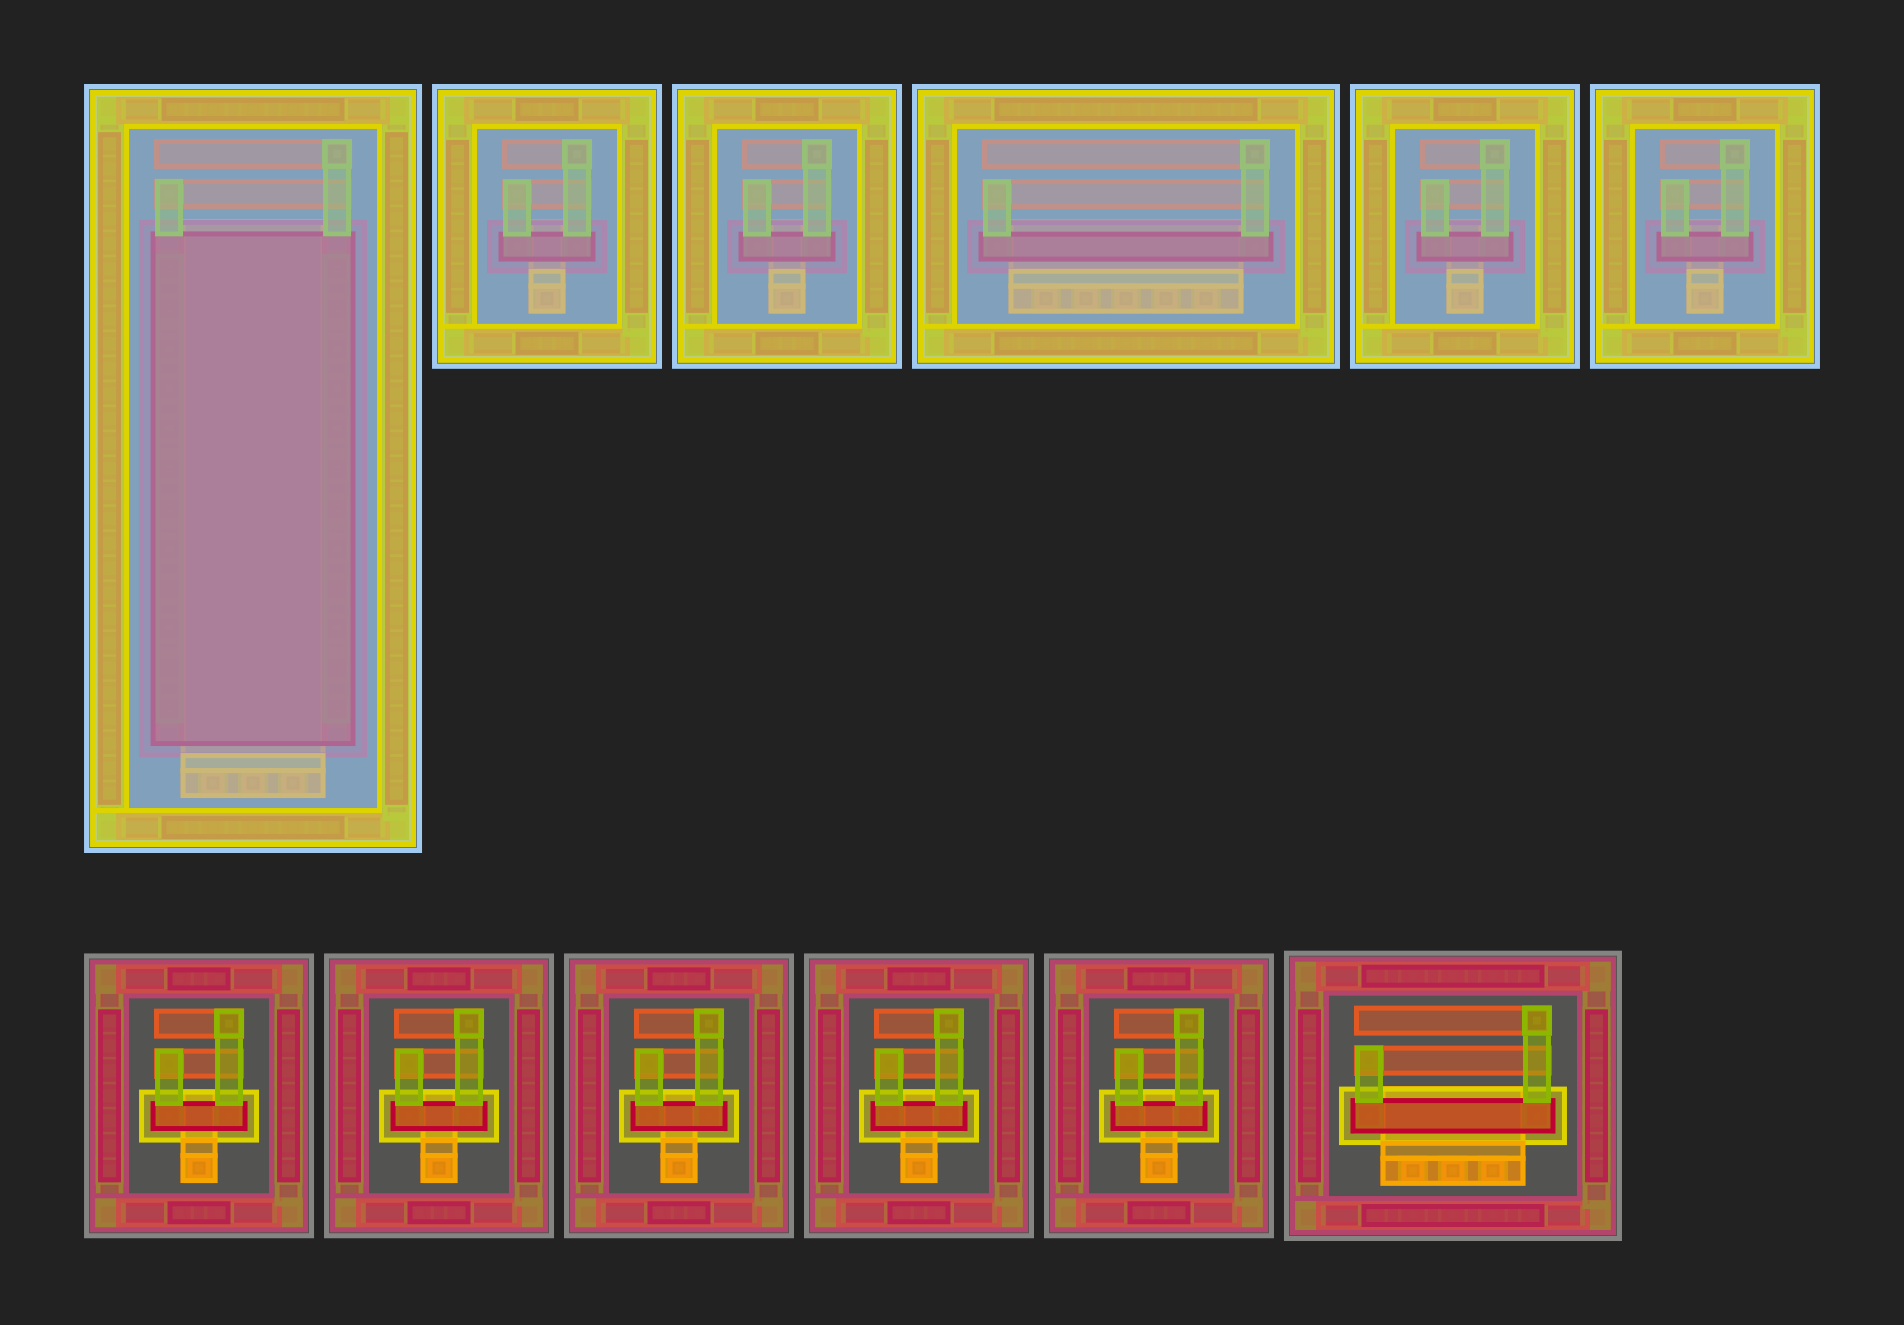

In [24]:
display_component(top_level, scale = 5,path=".")